In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Minimal RK4 step for scalars
def step_rk4(y, t, step, dy, **kwargs):
    y = float(y)
    half = step / 2.0
    k1 = dy(t, y, **kwargs)
    k2 = dy(t + half, y + k1 * half, **kwargs)
    k3 = dy(t + half, y + k2 * half, **kwargs)
    k4 = dy(t + step, y + k3 * step, **kwargs)
    return y + (step / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

In [3]:
def softmax(arr: np.ndarray) -> np.ndarray:
    exp = np.exp(arr)
    return exp / exp.sum()

In [5]:
import seaborn as sns
sns.set(style="whitegrid")


def pretty_plot_results(times, potentials, intensities, spikes, title="Simulation"):
    import numpy as _np
    times = _np.array(times)
    times_ms = times * 1000.0
    potentials = _np.array(potentials)
    intensities = _np.array(intensities)
    spikes = _np.array(spikes)

    fig, ax = plt.subplots(figsize=(12, 4.5))
    pal = sns.color_palette("deep")
    color_p = pal[0]
    color_i = pal[1]

    ax.plot(times_ms, potentials, color=color_p,
            lw=1.6, label="Membrane potential")
    ax.set_ylabel("Potential", color=color_p)
    ax.set_xlabel("Time (ms)")
    ax.tick_params(axis="y", labelcolor=color_p)

    ax2 = ax.twinx()
    ax2.fill_between(times_ms, intensities, color=color_i, alpha=0.25)
    ax2.plot(times_ms, intensities, color=color_i,
             lw=1.0, alpha=0.9, label="Intensity")
    ax2.set_ylabel("Intensity", color=color_i)
    ax2.tick_params(axis="y", labelcolor=color_i)

    # Plot spikes as vertical markers (raster-like) aligned to potential axis
    spike_times = times_ms[spikes.astype(
        bool)] if spikes.size else _np.array([])
    if spike_times.size > 0:
        ylim = ax.get_ylim()
        height = ylim[1] - ylim[0]
        line_y = ylim[0] + 0.85 * height
        ax.vlines(spike_times, line_y - 0.02 * height, line_y +
                  0.02 * height, color="red", alpha=0.9, linewidth=1.2)
        ax.scatter(spike_times, _np.ones_like(spike_times) * (line_y +
                   0.04 * height), color="red", s=18, zorder=5, label="Spikes")

    # Combined legend
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, loc="upper right", fontsize=9)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

In [6]:
STEP_SIZE = 1e-3  # s
SIMULATION_LENGTH = 0.5  # s
REFRACTORY_PERIOD = 5  # steps

times = np.arange(0, SIMULATION_LENGTH, STEP_SIZE)
delta_time = times[1] - times[0]

In [7]:
def sample_neurons(probabilities: np.ndarray) -> np.ndarray:

    # vectorized sampling per neuron: uniform random < p -> spike
    spikes = (np.random.random(size=probabilities.shape)
              < probabilities).astype(int)
    return spikes


def compute_signal(spikes: np.ndarray, weights: np.ndarray) -> float:
    return np.dot(spikes, weights)

In [19]:
TAU = 20  # ms
TAU_SYNAPSE = 5  # ms
INVERSE_TAU = 1 / TAU
REST_POTENTIAL = 0  # V
RESISTANCE = 1  # ohm
SPIKE_THRESHOLD = 1  # V

# Same for potentiation and depression but usually made different for each
LEARNING_WINDWOW = 1e-2

# Same for potentiation and depression but usually made different for each
POTENTIATION = 0.01
BASE_CURRENT = 1


def derivative_potential(t, membrane_potential, input_signal):
    return (RESISTANCE * input_signal - (membrane_potential - REST_POTENTIAL)) * INVERSE_TAU


def spiked(v: float, threshold: float) -> bool:
    return v >= threshold


def spike_response(v: float, v_rest: float) -> float:
    return v_rest


def delta_weights(delta_times: np.ndarray) -> np.ndarray:
    return np.sign(delta_times) * POTENTIATION * np.exp(-1 * np.abs(delta_times/LEARNING_WINDWOW))

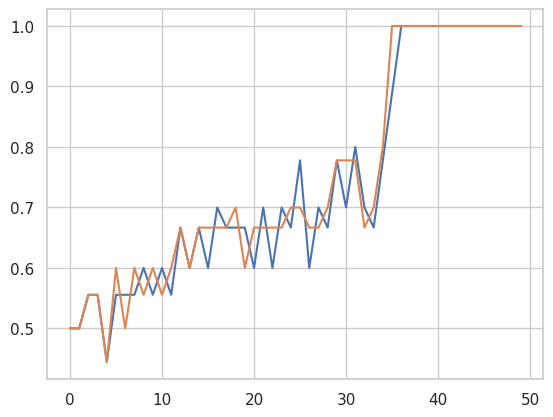

In [ ]:
# Max weight sum
MAX_WEIGHT_SUM = 5
WEIGHT_DECAY = 1 - 1e-3

# Firing patterns
rest_pattern = np.array([10, 10, 10, 10, 10, 100, 100, 100, 100, 100])
hand_pattern = np.array([100, 100, 100, 100, 100, 10, 10, 10, 10, 10])

firing_frequencies = np.array([rest_pattern, hand_pattern])
firing_probabilities = firing_frequencies * delta_time
firing_probabilities = np.clip(firing_probabilities, 0, 1)


# Output neuron weights
rest_weights = np.ones_like(rest_pattern) * 0.5
hand_weights = np.ones_like(hand_pattern) * 0.5

output_weights = np.array([rest_weights, hand_weights])


# Variable threshold voltages
thresholds = [SPIKE_THRESHOLD, SPIKE_THRESHOLD]
THRESHOLD_TAU = 0.1  # s
THRESHOLD_DELTA = 5e-2

EPOCHS = 50
N_CLASSES = output_weights.shape[0]

accuracies = np.zeros((N_CLASSES, EPOCHS))

for epoch in range(EPOCHS):
    for stimuls in range(N_CLASSES):

        # Each iteration initialize both neurons
        input_signal = np.zeros(firing_probabilities.shape[1])
        output_neuron_input = np.zeros(N_CLASSES)

        presynaptic_spike_times = np.zeros_like(input_signal) - np.inf

        spikes = np.zeros((N_CLASSES, times.shape[0]))
        postsynaptic_spike_times = np.zeros(N_CLASSES)
        spike_cooldowns = np.zeros(N_CLASSES)

        output_neuron_potentials = [REST_POTENTIAL, REST_POTENTIAL]
        competitive_potentials = [0, 0]
        # output_weights *= WEIGHT_DECAY

        for i, t in enumerate(times):

            output_neuron_input *= np.exp(-delta_time/TAU_SYNAPSE)

            # Shared for both neurons as the fire in parallel
            input_signal = sample_neurons(firing_probabilities[stimuls])

            for j, spike in enumerate(input_signal):
                if spike:
                    presynaptic_spike_times[j] = t

            for neuron in range(N_CLASSES):
                output_neuron_input[neuron] += compute_signal(
                    input_signal, output_weights[neuron]) + BASE_CURRENT

                if spike_cooldowns[neuron] > 0:
                    spike_cooldowns[neuron] -= 1
                    spikes[neuron][i] = 0

                    continue

                ret = step_rk4(output_neuron_potentials[neuron], t, STEP_SIZE,
                               derivative_potential, input_signal=output_neuron_input[neuron])

                ret -= competitive_potentials[neuron]

                output_neuron_potentials[neuron] = ret
                competitive_potentials[neuron] = 0

                if spiked(output_neuron_potentials[neuron], thresholds[neuron]):

                    spikes[neuron][i] = 1
                    postsynaptic_spike_times[neuron] = t
                    output_neuron_potentials[neuron] = spike_response(
                        output_neuron_potentials[neuron], REST_POTENTIAL)

                    competitive_potentials[not neuron] = thresholds[not neuron]
                    thresholds[neuron] += THRESHOLD_DELTA

                    spike_cooldowns[neuron] = REFRACTORY_PERIOD

                    if stimuls == neuron:
                        # vector
                        delta_t = postsynaptic_spike_times[neuron] - \
                            presynaptic_spike_times
                        output_weights[neuron] += delta_weights(
                            delta_t
                        )
                        weight_sum = output_weights[neuron].sum()
                        if weight_sum > MAX_WEIGHT_SUM:
                            output_weights[neuron] *= MAX_WEIGHT_SUM / \
                                weight_sum
                else:
                    spikes[neuron][i] = 0
                    thresholds[neuron] -= delta_time / \
                        THRESHOLD_TAU * THRESHOLD_DELTA

            # compute metrics
            total_spikes = spikes.sum()
            if total_spikes:
                accuracies[stimuls][epoch] = spikes[stimuls].sum() / \
                    total_spikes
            else:
                accuracies[stimuls][epoch] = 0

plt.plot(accuracies[0])
plt.plot(accuracies[1])
plt.show()

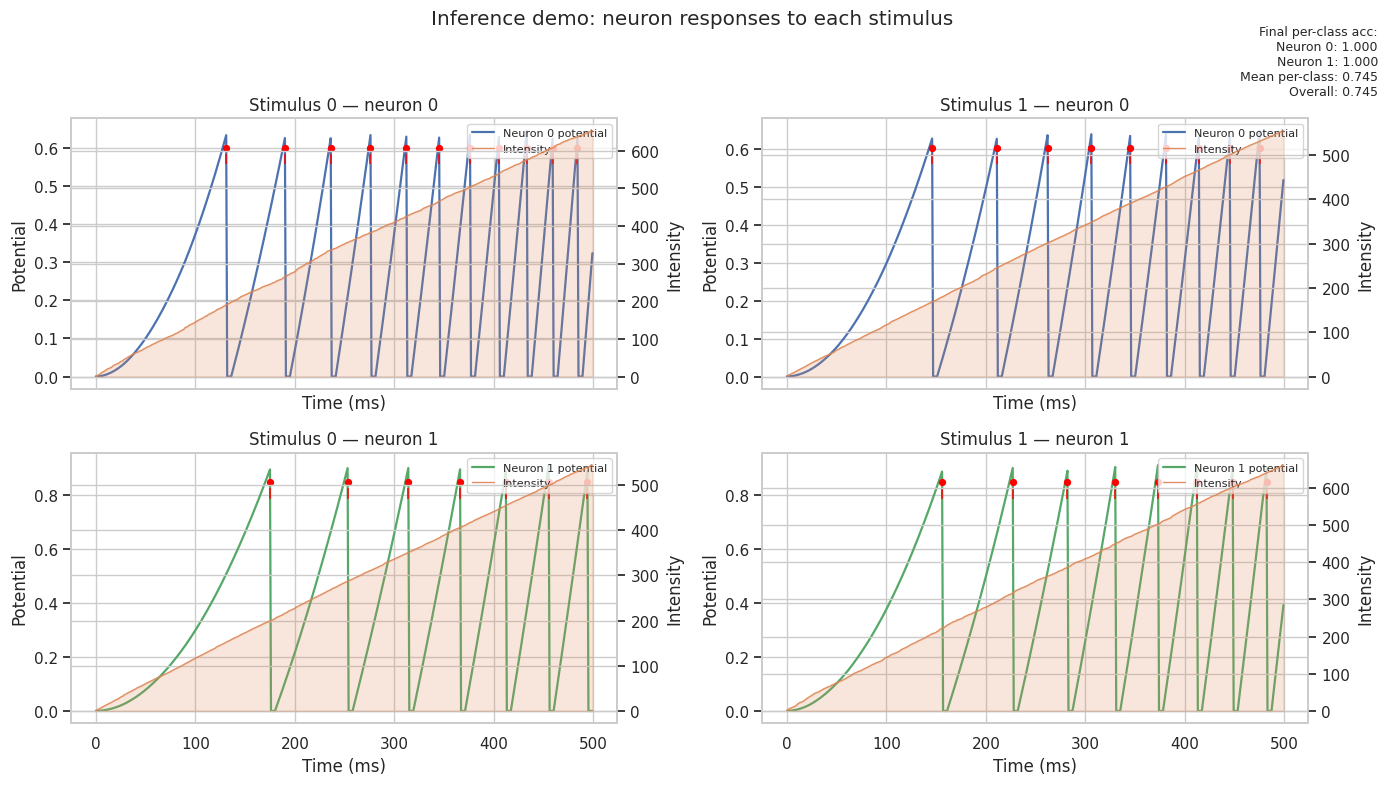

In [22]:
# Inference demo: run both stimuli and plot responses side-by-side
import numpy as _np
import matplotlib.pyplot as _plt
import seaborn as _sns
_sns.set(style="whitegrid")


def run_simulation_for_stimulus(stim_index, weights):
    output_neuron_potentials = _np.array(
        [REST_POTENTIAL, REST_POTENTIAL], dtype=float)
    output_neuron_input = _np.zeros(N_CLASSES)
    spike_cooldowns = _np.zeros(N_CLASSES, dtype=int)

    spikes = _np.zeros((N_CLASSES, times.size), dtype=int)
    potentials = _np.zeros((N_CLASSES, times.size), dtype=float)
    intensities = _np.zeros((N_CLASSES, times.size), dtype=float)

    for i, t in enumerate(times):
        output_neuron_input *= _np.exp(-delta_time/TAU_SYNAPSE)
        input_signal = sample_neurons(firing_probabilities[stim_index])

        for neuron in range(N_CLASSES):
            # accumulate synaptic input (no learning here)
            output_neuron_input[neuron] += compute_signal(
                input_signal, weights[neuron]) + BASE_CURRENT

            if spike_cooldowns[neuron] > 0:
                spike_cooldowns[neuron] -= 1
                spikes[neuron, i] = 0
                potentials[neuron, i] = output_neuron_potentials[neuron]
                intensities[neuron, i] = output_neuron_input[neuron]
                continue

            ret = step_rk4(output_neuron_potentials[neuron], t, STEP_SIZE,
                           derivative_potential, input_signal=output_neuron_input[neuron])
            output_neuron_potentials[neuron] = ret
            potentials[neuron, i] = ret
            intensities[neuron, i] = output_neuron_input[neuron]

            if spiked(ret, thresholds[neuron]):
                spikes[neuron, i] = 1
                output_neuron_potentials[neuron] = spike_response(
                    ret, REST_POTENTIAL)
                spike_cooldowns[neuron] = REFRACTORY_PERIOD

    return times, potentials, intensities, spikes


# Run inference for both stimuli using current trained weights
sim_results = []
for stim in range(firing_probabilities.shape[0]):
    sim_results.append(run_simulation_for_stimulus(stim, output_weights))

# Compute simple model statistics (if available)
if 'accuracies' in globals() and getattr(accuracies, 'size', 0):
    try:
        final_acc = accuracies[:, -1]
        mean_acc = accuracies.mean(axis=1)
        overall = accuracies.mean()
        stats_text = (
            f"Final per-class acc:\nNeuron 0: {final_acc[0]:.3f}\n"
            f"Neuron 1: {final_acc[1]:.3f}\nMean per-class: {mean_acc.mean():.3f}\nOverall: {overall:.3f}"
        )
    except Exception:
        stats_text = "Training stats present but could not compute summary"
else:
    stats_text = "No training stats available"

# Plot side-by-side: columns = stimuli, rows = neurons
fig, axes = _plt.subplots(2, 2, figsize=(14, 8), sharex=True)
pal = _sns.color_palette("deep")
times_ms = times * 1000.0
for col, (times_, potentials, intensities, spikes) in enumerate(sim_results):
    for neuron in range(N_CLASSES):
        ax = axes[neuron, col]
        color_p = pal[0] if neuron == 0 else pal[2]
        ax.plot(times_ms, potentials[neuron], color=color_p,
                lw=1.6, label=f"Neuron {neuron} potential")
        ax.set_ylabel("Potential")
        ax.set_xlabel("Time (ms)")

        ax2 = ax.twinx()
        ax2.fill_between(
            times_ms, intensities[neuron], color=pal[1], alpha=0.2)
        ax2.plot(times_ms, intensities[neuron], color=pal[1],
                 lw=1.0, alpha=0.9, label="Intensity")
        ax2.set_ylabel("Intensity")

        # spikes as vertical markers
        spike_times = times_ms[spikes[neuron].astype(
            bool)] if spikes.size else _np.array([])
        if spike_times.size > 0:
            ylim = ax.get_ylim()
            height = ylim[1] - ylim[0] if ylim[1] != ylim[0] else 1.0
            line_y = ylim[0] + 0.85 * height
            ax.vlines(spike_times, line_y - 0.02 * height, line_y +
                      0.02 * height, color="red", alpha=0.9, linewidth=1.2)
            ax.scatter(spike_times, _np.ones_like(spike_times) *
                       (line_y + 0.04 * height), color="red", s=18, zorder=5)

        # legends
        lines, labels = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines + lines2, labels + labels2,
                  loc="upper right", fontsize=8)
        ax.set_title(f"Stimulus {col} — neuron {neuron}")

# Annotate model stats in a rounded textbox at top-right
fig.text(0.99, 0.96, stats_text, ha='right', va='top', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

_plt.suptitle("Inference demo: neuron responses to each stimulus")
_plt.tight_layout(rect=[0, 0, 1, 0.94])
_plt.show()